# RAG Evaluation — RAGAS 0.4

Evaluates the RAG pipeline using the four core RAGAS metrics.

| Metric | What it measures |
|---|---|
| **Faithfulness** | Are all claims in the response supported by the retrieved contexts? |
| **Answer Relevancy** | Is the response focused on the question asked? |
| **Context Precision** | Are the relevant chunks ranked before the irrelevant ones? |
| **Context Recall** | Do the retrieved chunks cover everything needed by the reference answer? |

**LLM/Embeddings**: `gemini-2.5-flash` + `gemini-embedding-001` via `langchain-google-genai`

In [6]:
import sys, os, json, time, warnings, pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path('..').resolve()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

from app.config import configure_logging, get_settings
from rag.embeddings import build_embedding_fn
from rag.vector_store import VectorStore
from rag.parser import SectionStore
from agent.qa_agent import QAAgent
from tools.registry import ToolRegistry
from tools.search_documents import SearchDocumentsTool
from tools.extract_section import ExtractSectionTool

configure_logging()
settings = get_settings()

In [7]:
from ragas import evaluate, EvaluationDataset, SingleTurnSample
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
from ragas.run_config import RunConfig
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings

ragas_llm = LangchainLLMWrapper(
    ChatGoogleGenerativeAI(
        model=settings.gemini_model,
        google_api_key=settings.gemini_api_key,
    )
)
ragas_embeddings = LangchainEmbeddingsWrapper(
    GoogleGenerativeAIEmbeddings(
        model='models/gemini-embedding-001',
        google_api_key=settings.gemini_api_key,
    )
)

faithfulness.llm       = ragas_llm
answer_relevancy.llm   = ragas_llm
answer_relevancy.embeddings = ragas_embeddings
context_precision.llm  = ragas_llm
context_recall.llm     = ragas_llm

METRICS     = [faithfulness, answer_relevancy, context_precision, context_recall]
METRIC_COLS = ['faithfulness', 'answer_relevancy', 'context_precision', 'context_recall']
METRIC_LABELS = {
    'faithfulness':      'Faithfulness',
    'answer_relevancy':  'Answer\nRelevancy',
    'context_precision': 'Context\nPrecision',
    'context_recall':    'Context\nRecall',
}

print(f'Project root : {Path.cwd()}')
print(f'LLM          : {settings.gemini_model}')
print(f'Embedding    : {settings.embedding_model}')
print('RAGAS ready.')

Project root : C:\Users\luana\OneDrive\Projects\winnin
LLM          : gemini-2.5-flash
Embedding    : gemini-embedding-001
RAGAS ready.


In [8]:
doc_embed   = build_embedding_fn(settings.embedding_model, task_type='RETRIEVAL_DOCUMENT', api_key=settings.gemini_api_key)
query_embed = build_embedding_fn(settings.embedding_model, task_type='RETRIEVAL_QUERY',    api_key=settings.gemini_api_key)

vector_store = VectorStore(
    persist_dir=settings.chroma_persist_dir,
    collection_name=settings.chroma_collection_name,
    embedding_fn=doc_embed,
    query_embedding_fn=query_embed,
)
print(f'VectorStore  : {vector_store.count} chunks')

sections_path = Path('./persist/sections.pkl')
if sections_path.exists():
    with open(sections_path, 'rb') as f:
        section_store = pickle.load(f)
    print(f'SectionStore : loaded from {sections_path}')
else:
    section_store = SectionStore()
    print(f'⚠ SectionStore empty — run ingest.py first')

registry = ToolRegistry()
registry.register(SearchDocumentsTool(vector_store=vector_store))
registry.register(ExtractSectionTool(section_store=section_store))

agent = QAAgent(
    registry=registry,
    api_key=settings.gemini_api_key,
    model=settings.gemini_model,
    max_iterations=settings.agent_max_iterations,
)
print(f'Agent        : {settings.gemini_model}')

2026-04-24 18:55:00 | INFO     | rag.embeddings | Gemini embedding fn: model=gemini-embedding-001 task_type=RETRIEVAL_DOCUMENT
2026-04-24 18:55:01 | INFO     | rag.embeddings | Gemini embedding fn: model=gemini-embedding-001 task_type=RETRIEVAL_QUERY
2026-04-24 18:55:01 | INFO     | rag.vector_store | VectorStore initialized: collection='papers' persist_dir='./persist/chroma'


VectorStore  : 57 chunks
SectionStore : loaded from persist\sections.pkl


2026-04-24 18:55:02 | INFO     | agent.qa_agent | QAAgent initialized with model='gemini-2.5-flash' max_iter=5


Agent        : gemini-2.5-flash


In [9]:
EVAL_DATA = [
    {
        'question': 'What is the formula for scaled dot-product attention?',
        'reference': (
            'Scaled dot-product attention is computed as '
            'Attention(Q,K,V) = softmax(QK^T / sqrt(d_k)) * V, '
            'where Q, K, V are the query, key and value matrices and d_k is the key dimension.'
        ),
    },
    {
        'question': 'What are the two pre-training objectives used in BERT?',
        'reference': (
            'BERT is pre-trained with Masked Language Modeling (MLM), '
            'where 15% of tokens are masked and predicted, and '
            'Next Sentence Prediction (NSP), where the model predicts '
            'whether two sentences are consecutive.'
        ),
    },
    {
        'question': 'How does RAG combine a retriever with a generator?',
        'reference': (
            'RAG uses a Dense Passage Retriever (DPR) to retrieve the top-k '
            'relevant documents from a FAISS index, then feeds the query and '
            'retrieved documents together to a BART seq2seq generator that '
            'produces the final answer.'
        ),
    },
    {
        'question': 'What is the purpose of multi-head attention in the Transformer?',
        'reference': (
            'Multi-head attention allows the model to jointly attend to '
            'information from different representation subspaces at different '
            'positions, enabling it to capture diverse relationships in one layer.'
        ),
    },
    {
        'question': 'On which datasets was BERT pre-trained?',
        'reference': (
            'BERT was pre-trained on the BooksCorpus (800M words) and '
            'English Wikipedia (2,500M words), totalling approximately 3.3 billion words.'
        ),
    },
    {
        'question': 'What is the difference between RAG-Sequence and RAG-Token models?',
        'reference': (
            'RAG-Sequence uses the same retrieved document for the entire output sequence, '
            'marginalizing over documents per sequence. '
            'RAG-Token can use a different document for each generated token, '
            'marginalizing over documents at each decoding step.'
        ),
    },
    {
        'question': 'How does the Transformer encode the position of tokens?',
        'reference': (
            'The Transformer uses fixed positional encodings added to the input embeddings: '
            'PE(pos, 2i) = sin(pos / 10000^(2i/d_model)) and '
            'PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model)), '
            'allowing the model to attend to relative positions.'
        ),
    },
    {
        'question': 'How is BERT fine-tuned for extractive question answering?',
        'reference': (
            'For extractive QA (e.g., SQuAD), two learned vectors S and E are added. '
            'The probability of a token being the start/end of the answer span is '
            'computed via a dot product with S or E and a softmax. '
            'The span maximizing S·T_i + E·T_j is selected as the answer.'
        ),
    },
    {
        'question': 'What is the structure of the position-wise feed-forward network in the Transformer?',
        'reference': (
            'Each Transformer layer contains a position-wise FFN applied identically to each position: '
            'FFN(x) = max(0, xW1 + b1)W2 + b2, with inner dimension 2048 '
            'and input/output dimension 512.'
        ),
    },
    {
        'question': 'What retrieval mechanism does RAG use and how is it indexed?',
        'reference': (
            'RAG uses Dense Passage Retrieval (DPR): both questions and passages are encoded '
            'into dense vectors by BERT-based encoders. The passage index is built with FAISS '
            'for efficient Maximum Inner Product Search (MIPS).'
        ),
    },
]

print(f'{len(EVAL_DATA)} evaluation questions defined.')

10 evaluation questions defined.


In [10]:
PIPELINE_CACHE = Path('eval/pipeline_cache_v2.json')
TOP_K = 3

def retrieve(question: str) -> list[str]:
    results = vector_store.query(query_text=question, top_k=TOP_K)
    return [r['document'] for r in results]

def generate(question: str) -> str:
    time.sleep(3)  # avoid rate-limit on free tier
    try:
        return agent.answer(question)
    except Exception as exc:
        if '429' in str(exc) or 'RESOURCE_EXHAUSTED' in str(exc):
            print('  ⚠ Rate limit — waiting 60s...')
            time.sleep(60)
            return agent.answer(question)
        raise

# Load existing cache
if PIPELINE_CACHE.exists():
    with open(PIPELINE_CACHE, encoding='utf-8') as f:
        pipeline_rows = {r['question']: r for r in json.load(f)}
    print(f'Cache loaded — {len(pipeline_rows)} entries.')
else:
    pipeline_rows = {}

# Run missing questions
for i, item in enumerate(EVAL_DATA):
    q = item['question']
    if q in pipeline_rows:
        print(f'[{i+1}/{len(EVAL_DATA)}] ✓ (cached)  {q[:60]}')
        continue
    print(f'[{i+1}/{len(EVAL_DATA)}] Running    {q[:60]}')
    contexts = retrieve(q)
    answer   = generate(q)
    pipeline_rows[q] = {
        'question':  q,
        'answer':    answer,
        'contexts':  contexts,
        'reference': item['reference'],
    }
    print(f'         → {len(contexts)} chunks | answer: {len(answer)} chars')

# Save cache
PIPELINE_CACHE.parent.mkdir(parents=True, exist_ok=True)
with open(PIPELINE_CACHE, 'w', encoding='utf-8') as f:
    json.dump(list(pipeline_rows.values()), f, ensure_ascii=False, indent=2)

rows = [pipeline_rows[item['question']] for item in EVAL_DATA]
print(f'\n{len(rows)} pairs ready for evaluation.')

Cache loaded — 10 entries.
[1/10] ✓ (cached)  What is the formula for scaled dot-product attention?
[2/10] ✓ (cached)  What are the two pre-training objectives used in BERT?
[3/10] ✓ (cached)  How does RAG combine a retriever with a generator?
[4/10] ✓ (cached)  What is the purpose of multi-head attention in the Transform
[5/10] ✓ (cached)  On which datasets was BERT pre-trained?
[6/10] ✓ (cached)  What is the difference between RAG-Sequence and RAG-Token mo
[7/10] ✓ (cached)  How does the Transformer encode the position of tokens?
[8/10] ✓ (cached)  How is BERT fine-tuned for extractive question answering?
[9/10] ✓ (cached)  What is the structure of the position-wise feed-forward netw
[10/10] ✓ (cached)  What retrieval mechanism does RAG use and how is it indexed?

10 pairs ready for evaluation.


In [11]:
# ── Retrieved chunks per question ────────────────────────────────────────────

from IPython.display import display, HTML


def _score_color(s: float) -> str:
    if s >= 0.70:
        return "#27ae60"
    if s >= 0.50:
        return "#e67e22"
    return "#e74c3c"


def show_chunks(question: str, results: list) -> None:
    """Display retrieved chunks for a question as a styled HTML table."""
    if not results:
        display(HTML(f"""
        <div style="margin:10px 0;border:1px solid #bdc3c7;border-radius:6px;
                    overflow:hidden;font-family:sans-serif">
          <div style="background:#7f8c8d;color:white;padding:9px 14px;font-size:13px">
            {question}
          </div>
          <div style="padding:10px 14px;color:#e74c3c;font-style:italic">
            No chunks retrieved — VectorStore empty (run ingest.py first).
          </div>
        </div>"""))
        return

    chunk_rows = ""
    for i, r in enumerate(results):
        meta    = r["metadata"]
        paper   = meta.get("paper_id", "—")
        section = meta.get("section", "—")
        score   = r["score"]
        preview = r["document"][:350].replace("<", "&lt;").replace(">", "&gt;")
        chunk_rows += f"""
        <tr style="border-top:1px solid #e8e8e8">
          <td style="text-align:center;padding:6px 10px;font-weight:bold;color:#888">{i+1}</td>
          <td style="padding:6px 10px;min-width:130px;vertical-align:top">
            <b style="color:#2c3e50">{paper}</b><br>
            <small style="color:#7f8c8d">{section}</small>
          </td>
          <td style="text-align:center;padding:6px 10px;vertical-align:top">
            <span style="background:{_score_color(score)};color:white;
                         padding:3px 8px;border-radius:4px;font-size:12px;white-space:nowrap">
              {score:.3f}
            </span>
          </td>
          <td style="padding:6px 10px;font-size:12px;color:#444;line-height:1.6;vertical-align:top">
            {preview}&hellip;
          </td>
        </tr>"""

    display(HTML(f"""
    <div style="margin:14px 0;border:1px solid #bdc3c7;border-radius:6px;
                overflow:hidden;font-family:sans-serif">
      <div style="background:#2c3e50;color:white;padding:9px 14px;font-size:13px;font-weight:bold">
        {question}
      </div>
      <table style="width:100%;border-collapse:collapse;background:white">
        <thead>
          <tr style="background:#ecf0f1;color:#555;font-size:12px">
            <th style="padding:6px 10px">#</th>
            <th style="padding:6px 10px;text-align:left">Paper / Section</th>
            <th style="padding:6px 10px">Score</th>
            <th style="padding:6px 10px;text-align:left">Retrieved passage</th>
          </tr>
        </thead>
        <tbody>{chunk_rows}</tbody>
      </table>
    </div>"""))


print("Retrieved chunks per question:\n")
for row in rows:
    full_results = vector_store.query(row["question"], top_k=TOP_K)
    show_chunks(row["question"], full_results)

Retrieved chunks per question:



2026-04-24 18:55:03 | INFO     | httpx | HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-embedding-001:batchEmbedContents "HTTP/1.1 200 OK"


#,Paper / Section,Score,Retrieved passage
1,attention methodology,0.741,"softmax function to obtain the weights on the values. In practice, we compute the attention function on a set of queries simultaneously, packed together into a matrix Q . The keys and values are also packed together into matrices K and V . We compute the matrix of outputs as: The two most commonly used attention functions are additive attention [2]…"
2,attention methodology,0.690,"Most competitive neural sequence transduction models have an encoder-decoder structure [5, 2, 35]. Here, the encoder maps an input sequence of symbol representations ( x 1 , ..., x n ) to a sequence of continuous representations z = ( z 1 , ..., z n ) . Given z , the decoder then generates an output sequence ( y 1 , ..., y m ) of symbols one elemen…"
3,attention methodology,0.677,"position in the decoder to attend over all positions in the input sequence. This mimics the typical encoder-decoder attention mechanisms in sequence-to-sequence models such as [38, 2, 9]. The encoder contains self-attention layers. In a self-attention layer all of the keys, values and queries come from the same place, in this case, the output of th…"


2026-04-24 18:55:04 | INFO     | httpx | HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-embedding-001:batchEmbedContents "HTTP/1.1 200 OK"


#,Paper / Section,Score,Retrieved passage
1,bert related_work,0.784,"data generator chooses 15% of the token positions at random for prediction. If the i -th token is chosen, we replace the i -th token with (1) the [MASK] token 80% of the time (2) a random token 10% of the time (3) the unchanged i -th token 10% of the time. Then, T i will be used to predict the original token with cross entropy loss. We compare vari…"
2,bert introduction,0.782,"Language model pre-training has been shown to be effective for improving many natural language processing tasks (Dai and Le, 2015; Peters et al., 2018a; Radford et al., 2018; Howard and Ruder, 2018). These include sentence-level tasks such as natural language inference (Bowman et al., 2015; Williams et al., 2018) and paraphrasing (Dolan and Brocket…"
3,bert related_work,0.781,"sentences packed together. We use WordPiece embeddings (Wu et al., 2016) with a 30,000 token vocabulary. The first token of every sequence is always a special classification token ( [CLS] ). The final hidden state corresponding to this token is used as the aggregate sequence representation for classification tasks. Sentence pairs are packed togethe…"


...

#,Paper / Section,Score,Retrieved passage
1,bert experiments,0.770,"computed as a dot product between T i and S followed by a softmax over all of the words in the paragraph: P i = e S · T i ∑ j e S · T j . The analogous formula is used for the end of the answer span. The score of a candidate span from position i to position j is defined as S · T i + E · T j , and the maximum scoring span where j ≥ i is used as a pr…"
2,bert experiments,0.761,"In this section, we present BERT fine-tuning results on 11 NLP tasks. The General Language Understanding Evaluation (GLUE) benchmark (Wang et al., 2018a) is a collection of diverse natural language understanding tasks. Detailed descriptions of GLUE datasets are included in Appendix B.1. To fine-tune on GLUE, we represent the input sequence (for sin…"
3,rag discussion,0.744,", November 2016. URL http: //arxiv.org/abs/1611.09268 . arXiv: 1611.09268. Petr Baudiš and Jan Šediv` y. Modeling of the question answering task in the yodaqa system. In International Conference of the Cross-Language Evaluation Forum for European Languages , pages 222-228. Springer, 2015. URL https://link.springer.com/chapter/10.1007% 2F978-3-319-2…"


2026-04-24 18:55:08 | INFO     | httpx | HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-embedding-001:batchEmbedContents "HTTP/1.1 200 OK"


#,Paper / Section,Score,Retrieved passage
1,attention methodology,0.745,"Most competitive neural sequence transduction models have an encoder-decoder structure [5, 2, 35]. Here, the encoder maps an input sequence of symbol representations ( x 1 , ..., x n ) to a sequence of continuous representations z = ( z 1 , ..., z n ) . Given z , the decoder then generates an output sequence ( y 1 , ..., y m ) of symbols one elemen…"
2,attention methodology,0.738,"position in the decoder to attend over all positions in the input sequence. This mimics the typical encoder-decoder attention mechanisms in sequence-to-sequence models such as [38, 2, 9]. The encoder contains self-attention layers. In a self-attention layer all of the keys, values and queries come from the same place, in this case, the output of th…"
3,attention methodology,0.725,"softmax function to obtain the weights on the values. In practice, we compute the attention function on a set of queries simultaneously, packed together into a matrix Q . The keys and values are also packed together into matrices K and V . We compute the matrix of outputs as: The two most commonly used attention functions are additive attention [2]…"


2026-04-24 18:55:08 | INFO     | httpx | HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-embedding-001:batchEmbedContents "HTTP/1.1 200 OK"


#,Paper / Section,Score,Retrieved passage
1,rag introduction,0.791,"RAG-Sequence and RAG-Token are equivalent. The retrieval component p η ( z | x ) is based on DPR [26]. DPR follows a bi-encoder architecture: where d ( z ) is a dense representation of a document produced by a BERTBASE document encoder [8], and q ( x ) a query representation produced by a query encoder , also based on BERTBASE. Calculating top-k ( …"
2,rag introduction,0.767,"outperforms previous extractive approaches. For knowledge-intensive generation, we experiment with MS-MARCO [1] and Jeopardy question generation, and we find that our models generate responses that are more factual, specific, and diverse than a BART baseline. For FEVER [56] fact verification, we achieve results within 4.3% of state-of-the-art pipel…"
3,rag experiments,0.759,"We experiment with RAG in a wide range of knowledge-intensive tasks. For all experiments, we use a single Wikipedia dump for our non-parametric knowledge source. Following Lee et al. [31] and Karpukhin et al. [26], we use the December 2018 dump. Each Wikipedia article is split into disjoint 100-word chunks, to make a total of 21M documents. We use …"


In [12]:
SCORES_CACHE = Path('eval/scores_cache_v2.json')

if SCORES_CACHE.exists():
    df = pd.read_json(SCORES_CACHE)
    print(f'Scores loaded from cache ({len(df)} rows).')
else:
    samples = [
        SingleTurnSample(
            user_input=r['question'],
            response=r['answer'],
            retrieved_contexts=r['contexts'],
            reference=r['reference'],
        )
        for r in rows
    ]

    dataset    = EvaluationDataset(samples=samples)
    run_config = RunConfig(timeout=180, max_retries=6, max_wait=60)

    print('Starting RAGAS evaluation...')
    result = evaluate(
        dataset=dataset,
        metrics=METRICS,
        llm=ragas_llm,
        embeddings=ragas_embeddings,
        run_config=run_config,
    )

    df = result.to_pandas().rename(columns={'user_input': 'question', 'response': 'answer'})
    SCORES_CACHE.parent.mkdir(parents=True, exist_ok=True)
    df.to_json(SCORES_CACHE, orient='records', indent=2)
    print(f'Scores saved → {SCORES_CACHE}')

df['avg'] = df[METRIC_COLS].mean(axis=1)

means = df[METRIC_COLS].mean()
print('\n── Mean scores ──────────────────────────────')
for col in METRIC_COLS:
    print(f'  {col:24s} {means[col]:.4f}')
print(f'  {"overall average":24s} {df["avg"].mean():.4f}')

Scores loaded from cache (10 rows).

── Mean scores ──────────────────────────────
  faithfulness             0.9392
  answer_relevancy         0.8403
  context_precision        0.9167
  context_recall           0.9000
  overall average          0.8990


In [13]:
col_rename = {c: METRIC_LABELS[c].replace('\n', ' ') for c in METRIC_COLS}
col_rename.update({'question': 'Question', 'avg': 'Average'})

display_df = df[['question'] + METRIC_COLS + ['avg']].copy()
display_df['question'] = display_df['question'].str[:55] + '...'
display_df = display_df.rename(columns=col_rename)

score_cols = [c for c in display_df.columns if c != 'Question']

display(display_df.style
    .background_gradient(cmap='RdYlGn', subset=score_cols, vmin=0, vmax=1)
    .format({c: '{:.3f}' for c in score_cols})
    .hide(axis='index')
)

Question,Faithfulness,Answer Relevancy,Context Precision,Context Recall,Average
What is the formula for scaled dot-product attention?...,0.727,0.838,1.000,1.000,0.891
What are the two pre-training objectives used in BERT?...,1.000,0.859,1.000,1.000,0.965
How does RAG combine a retriever with a generator?...,1.000,0.816,1.000,0.000,0.704
What is the purpose of multi-head attention in the Tran...,1.000,0.823,1.000,1.000,0.956
On which datasets was BERT pre-trained?...,0.818,0.860,1.000,1.000,0.920
What is the difference between RAG-Sequence and RAG-Tok...,1.000,0.906,1.000,1.000,0.976
How does the Transformer encode the position of tokens?...,0.846,0.865,0.833,1.000,0.886
How is BERT fine-tuned for extractive question answerin...,1.000,0.812,1.000,1.000,0.953
What is the structure of the position-wise feed-forward...,1.000,0.851,0.500,1.000,0.838
What retrieval mechanism does RAG use and how is it ind...,1.000,0.773,0.833,1.000,0.902


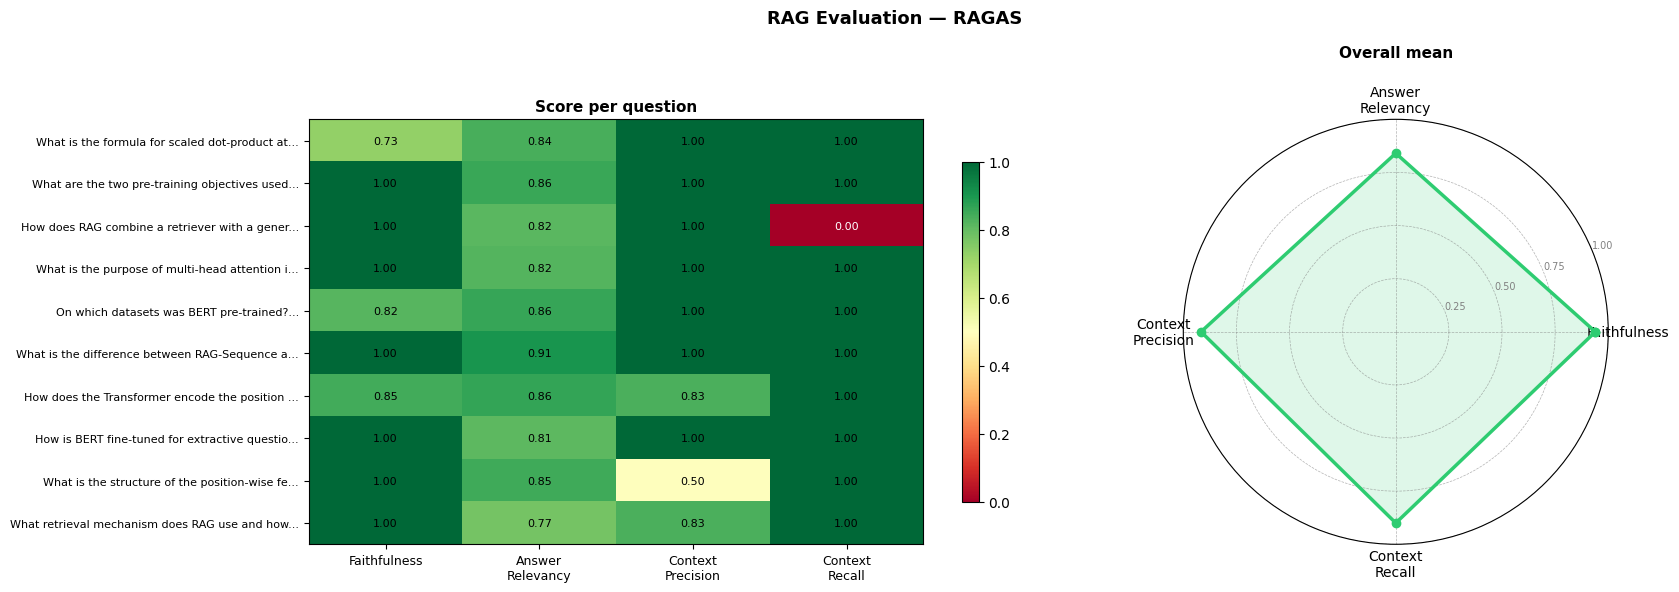

In [14]:
score_matrix    = df[METRIC_COLS].values
questions_short = [q[:45] + '...' for q in df['question']]
cats            = [METRIC_LABELS[c] for c in METRIC_COLS]

fig = plt.figure(figsize=(18, 6))

ax1 = fig.add_subplot(1, 2, 1)
im  = ax1.imshow(score_matrix, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax1.set_xticks(range(len(METRIC_COLS)))
ax1.set_xticklabels(cats, fontsize=9)
ax1.set_yticks(range(len(questions_short)))
ax1.set_yticklabels(questions_short, fontsize=8)
ax1.set_title('Score per question', fontsize=11, fontweight='bold')
for i in range(score_matrix.shape[0]):
    for j in range(score_matrix.shape[1]):
        v = score_matrix[i, j]
        ax1.text(j, i, f'{v:.2f}', ha='center', va='center',
                 fontsize=8, color='white' if v < 0.4 else 'black')
plt.colorbar(im, ax=ax1, shrink=0.8)

# Radar
ax2    = fig.add_subplot(1, 2, 2, polar=True)
N      = len(cats)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles_closed = angles + angles[:1]
vals   = means[METRIC_COLS].tolist()
vals_closed = vals + vals[:1]

ax2.plot(angles_closed, vals_closed, 'o-', lw=2.5, color='#2ecc71')
ax2.fill(angles_closed, vals_closed, alpha=0.15, color='#2ecc71')
ax2.set_xticks(angles)
ax2.set_xticklabels(cats, fontsize=10)
ax2.set_ylim(0, 1)
ax2.set_yticks([0.25, 0.5, 0.75, 1.0])
ax2.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], fontsize=7, color='grey')
ax2.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.6)
ax2.set_title('Overall mean', fontsize=11, fontweight='bold', pad=20)

plt.suptitle('RAG Evaluation — RAGAS', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ragas_results_v2.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
ADVICE = {
    'faithfulness':      'Agent generating claims beyond the context → tighten the system prompt or reduce max_iterations.',
    'answer_relevancy':  'Responses drifting off-topic → strengthen the focus instruction in the system prompt.',
    'context_precision': 'Irrelevant chunks ranked high → try a larger embedding model or add a re-ranker.',
    'context_recall':    'Retriever missing required information → increase top_k or reduce chunk_size.',
}

print('═' * 55)
print('  DIAGNOSIS')
print('═' * 55)
for col in METRIC_COLS:
    score = means[col]
    icon  = '✅' if score >= 0.70 else ('⚠ ' if score >= 0.50 else '❌')
    label = METRIC_LABELS[col].replace('\n', ' ')
    print(f'\n{icon} {label:22s}  {score:.3f}')
    if score < 0.70:
        print(f'   → {ADVICE[col]}')

print(f'\n\n── Worst-performing questions (by average score) ──')
for _, row in df.nsmallest(3, 'avg').iterrows():
    print(f"  {row['avg']:.3f}  {row['question'][:65]}")

═══════════════════════════════════════════════════════
  DIAGNOSIS
═══════════════════════════════════════════════════════

✅ Faithfulness            0.939

✅ Answer Relevancy        0.840

✅ Context Precision       0.917

✅ Context Recall          0.900


── Worst-performing questions (by average score) ──
  0.704  How does RAG combine a retriever with a generator?
  0.838  What is the structure of the position-wise feed-forward network i
  0.886  How does the Transformer encode the position of tokens?


In [ ]:
import logging
import re
from pathlib import Path
from typing import NamedTuple

logger = logging.getLogger(__name__)

SECTION_ALIASES: dict[str, str] = {
    "abstract": "abstract",
    "1 introduction": "introduction",
    "introduction": "introduction",
    "2 background": "related_work",
    "related work": "related_work",
    "background": "related_work",
    "3 model architecture": "methodology",
    "model architecture": "methodology",
    "method": "methodology",
    "methodology": "methodology",
    "approach": "methodology",
    "4 training": "experiments",
    "experiments": "experiments",
    "experimental setup": "experiments",
    "training": "experiments",
    "5 results": "results",
    "results": "results",
    "6 conclusion": "conclusion",
    "conclusion": "conclusion",
    "conclusions": "conclusion",
    "discussion": "discussion",
}


class ParsedSection(NamedTuple):
    name: str        # chave normalizada
    raw_name: str    # nome original no paper
    text: str
    page_start: int


class ParsedPaper(NamedTuple):
    paper_id: str
    title: str
    full_text: str
    sections: list[ParsedSection]


def _normalize_section_name(raw: str) -> str | None:
    cleaned = raw.strip().lower()
    cleaned_no_num = re.sub(r"^\d+\.?\s+", "", cleaned)
    return SECTION_ALIASES.get(cleaned) or SECTION_ALIASES.get(cleaned_no_num)


def parse_pdf(pdf_path: Path, paper_id: str, title: str) -> ParsedPaper:
    """
    Extrai texto e seções de um PDF científico usando Docling.
    Retorna um ParsedPaper com full_text (markdown) e lista de ParsedSection.
    """
    from docling.document_converter import DocumentConverter

    logger.info("Parsing PDF with Docling: %s", pdf_path)

    converter = DocumentConverter()
    result = converter.convert(str(pdf_path))
    doc = result.document

    full_text = doc.export_to_markdown()
    sections = _extract_sections(doc)

    logger.info(
        "Parsed '%s': %d chars, %d sections detected",
        paper_id,
        len(full_text),
        len(sections),
    )

    return ParsedPaper(
        paper_id=paper_id,
        title=title,
        full_text=full_text,
        sections=sections,
    )


def _extract_sections(doc) -> list[ParsedSection]:
    from docling_core.types.doc import DocItemLabel

    BODY_LABELS = {
        DocItemLabel.TEXT,
        DocItemLabel.PARAGRAPH,
        DocItemLabel.LIST_ITEM,
        DocItemLabel.FORMULA,
    }

    sections: list[ParsedSection] = []
    current_name: str | None = None
    current_raw: str = ""
    current_lines: list[str] = []
    current_page: int = 0

    for item, _ in doc.iterate_items():
        text = getattr(item, "text", "") or ""

        if item.label == DocItemLabel.SECTION_HEADER:
            normalized = _normalize_section_name(text)
            if normalized:
                if current_name and current_lines:
                    sections.append(ParsedSection(
                        name=current_name,
                        raw_name=current_raw,
                        text="\n".join(current_lines).strip(),
                        page_start=current_page,
                    ))
                prov = getattr(item, "prov", None)
                current_name = normalized
                current_raw = text.strip()
                current_lines = []
                current_page = prov[0].page_no if prov else 0

        elif item.label in BODY_LABELS and current_name and text:
            current_lines.append(text)

    if current_name and current_lines:
        sections.append(ParsedSection(
            name=current_name,
            raw_name=current_raw,
            text="\n".join(current_lines).strip(),
            page_start=current_page,
        ))

    return sections


class SectionStore:
    """
    Armazena seções extraídas dos papers para acesso pela ExtractSectionTool.
    Interface simples: get_section(paper_id, section) → str | None.
    """

    def __init__(self) -> None:
        self._store: dict[str, dict[str, str]] = {}

    def add_paper(self, parsed: ParsedPaper) -> None:
        self._store[parsed.paper_id] = {
            section.name: section.text for section in parsed.sections
        }
        logger.debug(
            "SectionStore: added '%s' with sections: %s",
            parsed.paper_id,
            list(self._store[parsed.paper_id].keys()),
        )

    def get_section(self, paper_id: str, section: str) -> str | None:
        paper = self._store.get(paper_id)
        if paper is None:
            return None
        return paper.get(section)

    def list_sections(self, paper_id: str) -> list[str]:
        return list(self._store.get(paper_id, {}).keys())

PAPERS: dict[str, dict[str, str]] = {
    "attention": {
        "arxiv_id": "1706.03762",
        "title": "Attention Is All You Need",
        "url": "https://arxiv.org/pdf/1706.03762.pdf",
    },
    "bert": {
        "arxiv_id": "1810.04805",
        "title": "BERT: Pre-training of Deep Bidirectional Transformers",
        "url": "https://arxiv.org/pdf/1810.04805.pdf",
    },
    "rag": {
        "arxiv_id": "2005.11401",
        "title": "Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks",
        "url": "https://arxiv.org/pdf/2005.11401.pdf",
    },
}

parsed = parse_pdf(Path(r'\Users\luana\OneDrive\Projects\winnin\data\papers\attention.pdf'),
          PAPERS['attention']['arxiv_id'],
          PAPERS['attention']['title'])

2026-04-24 18:55:09 | INFO     | __main__ | Parsing PDF with Docling: \Users\luana\OneDrive\Projects\winnin\data\papers\attention.pdf
2026-04-24 18:55:09 | INFO     | docling.datamodel.document | detected formats: [<InputFormat.PDF: 'pdf'>]
2026-04-24 18:55:09 | INFO     | docling.document_converter | Going to convert document batch...
2026-04-24 18:55:09 | INFO     | docling.document_converter | Initializing pipeline for StandardPdfPipeline with options hash 80a8a1322ca5ef46817c7adbf875fff6
2026-04-24 18:55:09 | INFO     | docling.utils.accelerator_utils | Accelerator device: 'cpu'
[INFO] 2026-04-24 18:55:09,851 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-04-24 18:55:09,856 [RapidOCR] download_file.py:60: File exists and is valid: C:\Users\luana\OneDrive\Projects\winnin\.venv\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-04-24 18:55:09,856 [RapidOCR] main.py:57: Using C:\Users\luana\OneDrive\Projects\winnin\.venv\Lib\site-packages\rapi

In [17]:
print(f"--- Seções encontradas em: {parsed.title} ---")
for sec in parsed.sections:
    print(f"Chave: {sec.name:15} | Original: {sec.raw_name}")

--- Seções encontradas em: Attention Is All You Need ---
Chave: abstract        | Original: Abstract
Chave: introduction    | Original: 1 Introduction
Chave: related_work    | Original: 2 Background
Chave: methodology     | Original: 3 Model Architecture
Chave: experiments     | Original: 5 Training
Chave: results         | Original: 6 Results
Chave: conclusion      | Original: 7 Conclusion


In [18]:
print([section.name for section in parsed.sections])

['abstract', 'introduction', 'related_work', 'methodology', 'experiments', 'results', 'conclusion']


In [19]:
parsed

ParsedPaper(paper_id='1706.03762', title='Attention Is All You Need', full_text='Provided proper attribution is provided, Google hereby grants permission to reproduce the tables and figures in this paper solely for use in journalistic or scholarly works.\n\n## Attention Is All You Need\n\nAshish Vaswani ∗ Google Brain avaswani@google.com Noam Shazeer ∗ Google Brain noam@google.com\n\nLlion Jones ∗ Google Research llion@google.com Niki Parmar ∗ Google Research nikip@google.com Aidan N. Gomez ∗ † University of Toronto aidan@cs.toronto.edu Jakob Uszkoreit ∗ Google Research usz@google.com Łukasz Kaiser ∗ Google Brain lukaszkaiser@google.com Illia Polosukhin ∗ ‡\n\nillia.polosukhin@gmail.com\n\n## Abstract\n\nThe dominant sequence transduction models are based on complex recurrent or convolutional neural networks that include an encoder and a decoder. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture,